In [1]:
%run general_functions.ipynb

In [2]:
# data path
dataPath = '/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/'
# variable names
vars = ['ALK', 'DIC', 'fco2', 'co2flux', 'ph', 'mld']
scenarios = ['base26', 'oae26', 'base70', 'oae70']

final = 'lastDecade.nc'

filePath = {}

for var in vars:
    filePath[var] = {}

    for scenario in scenarios:
        filePath[var][scenario] = dataPath + var + f'_{scenario}_' + final

# variable units
varUnit = {
                    'ALK' : {'Alkalinity' : r'μ mol $\mathregular{kg^{-1}}$'},
                    'DIC' : {'DIC' : r'μ mol $\mathregular{kg^{-1}}$'},
                    'co2flux' : {'$\mathregular{CO_{2}}$ flux' : r'kg $\mathregular{m^{-2} \ yr^{-1}}$'},
                    'fco2' : {'Ocean p$\mathregular{CO_{2}}$' : r'μatm'},
                    'ph': {'pH': 'unit'},
                    'somxl010': {'MLD': 'm'}
                                    
               }

In [3]:
# if input data is global, slicing is needed with ' data.sel(x=slice(520, 595), y=slice(330, 435)) ' (european region)

In [4]:
# ocean mask

mesk_mask = xr.open_dataset(dataPath+'mesh_mask.nc')
dx, dy = mesk_mask.e1t, mesk_mask.e2t
grid_cell_area = (dx * dy).isel(t=0)

mesk_mask['tmask'] = mesk_mask['tmask'].where(mesk_mask['tmask']!=0)
grid_cell_ocean = (mesk_mask['tmask'].isel(t=0,z=0)*grid_cell_area)
grid_cell_ocean = grid_cell_ocean.where(grid_cell_ocean)

ocean_slice = grid_cell_ocean.sel(x=slice(520, 595), y=slice(330, 435)) # m-2

In [5]:
# alkalkinity mask

alk_mask = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/alk_mask/alkalinity_mask_y2100.nc')
alk_mask = alk_mask.where(alk_mask)
alk_mask=alk_mask.sel(x=slice(520, 595), y=slice(330, 435))
alk_mask = xr.where(alk_mask.notnull(), 1, np.nan)
alk_mask = alk_mask.where(alk_mask)

In [6]:
def geo_weight(data, var):
    
    weights = np.cos(np.deg2rad(data.nav_lat))
    weights.name = "weights"

    data_weighted = data.weighted(weights)
    weighted_mean = data_weighted.mean(dim=("x", "y"))
    
    return weighted_mean

In [7]:
def create_discrete_cmap(cmap, n):

    colors = cmap(np.linspace(0, 1, n))
    discrete_cmap = mcolors.ListedColormap(colors)
    bounds = np.linspace(0, 100, n+1)
    norm = mcolors.BoundaryNorm(bounds, discrete_cmap.N)
    
    return discrete_cmap, norm
    
n = 25

In [8]:
# function to compute the difference between oae and baseline scenarios
def comp(baseline, oae, var):
    delta = oae-baseline
    return delta

In [19]:
# slice variable to mixed layer depth
def slicing(data, mld, var):
    # slice to mixed layer depth level
    if var == 'other':
        data = data * ocean_slice * 1e-9
        data = data.groupby('time_counter.year').mean('time_counter')
        # mld_bool = (data.deptht > (mld.somxl010.groupby('time_counter.year').max(dim='time_counter'))).to_dataset(name='somxl010') 
        mld_bool = (data.deptht > 200).to_dataset(name='somxl010') # depth threshold
    else:
        mld_bool = (data.deptht < mld.somxl010).to_dataset(name='somxl010') 
    # data * boolean
    data *= mld_bool.somxl010
    # fill nans with 0s #####  * 1025 * 1e-6 # kg m-3  #####
    data = data.fillna(0)
    # calculate weights based on ocean layer length
    layers_sum = [
        data[var].isel(deptht=x) * (data.deptht[x] if x == 0 else (data.deptht[x] - data.deptht[x - 1]))
        for x in range(len(data.deptht))
    ]
    # sum up all layers and divide by mld length
    if var == 'other':
        weighted_var = (sum(layers_sum)).to_dataset(name=var)
    else:
        weighted_var = (sum(layers_sum) / mld.somxl010).to_dataset(name=var)
    weighted_var = weighted_var.where(weighted_var)
    
    return weighted_var

In [10]:
def compute_integral(data, var):
    data = data * ocean_slice * 1e-9
    data = data.fillna(0) * 1025 * 1e-6 # mol m-3
    layers_sum = [
        data[var].isel(deptht=x) * (data.deptht[x] if x == 0 else (data.deptht[x] - data.deptht[x - 1]))
        for x in range(len(data.deptht))
    ]
    weighted_var = sum(layers_sum).to_dataset(name=var)
    weighted_var = weighted_var.where(weighted_var)
    
    return weighted_var

In [11]:
def lin_regr(data, var):
    t = np.arange(len(data.time_counter))
    y = data[var]
    slope, intercept, r_value, p_value, std_err = linregress(t, y)
    y_pred = intercept + slope * t
    return y_pred

In [12]:
def fig_plot_map(data, var, ax, vmin, vmax, oae_index, base_index):
    # get the difference between oae and baseline over time, then compute the 10-year mean
    if var != 'DIC':
        da = (list(data.values())[oae_index].mean('year')-list(data.values())[base_index].mean('year'))[var]
    else:
        da = (list(data.values())[oae_index].isel(year=-1)-list(data.values())[base_index].isel(year=-1))[var]
    
    im = ax.pcolormesh(
        da,
        cmap=cmap,
        vmin=vmin,vmax=vmax,
        shading='auto'
    )

    return im

In [13]:
def annualavg(data, var):
    monthLength = data.time_counter.dt.days_in_month
    monthly_avg = (data * monthLength).groupby("time_counter.month").mean(dim="time_counter") / monthLength.groupby("time_counter.month").mean(dim="time_counter")
    
    return monthly_avg

In [14]:
# define figures 

In [15]:
# time slice
tStart, tStop = '2090', '2100'

d = '$^\circ$' 
lat_label = [f'37{d}N', f'43{d}N',f'49{d}N', f'55{d}N', f'61{d}N', f'68{d}N',f'75{d}N'] 
lon_label = [f'28{d}W', f'20{d}W', f'12{d}W',f'4{d}W', f'4{d}E',f'12{d}E']

In [25]:
def process_scenario(var, filePath):
    # load datasets
    var_datasets = {
        scenario: xr.open_dataset(path, decode_times=True)
        for scenario, path in filePath[var].items()
    }
    # load mixed layer depth datasets
    mld_datasets = {
        scenario: xr.open_dataset(path, decode_times=True)
        for scenario, path in filePath['mld'].items()
    }

    nodepth_datasets = {}
    map_datasets = {}
    integral = {}
    
    for scenario, dataset in var_datasets.items():
        dataset = dataset.where(dataset)
        # set variables that are sliced to mld
        # if var in ['ALK','DIC']:
        #     datasetMLD = mld_datasets[scenario]
        #     dataset = slicing(dataset, datasetMLD, var)
            
        if var in ['ALK']: # for surface alkalinity plots
            dataset = dataset.isel(deptht=0)
        
        # elif var in ['DIC']: # for surface alkalinity plots
                                  # mol m-3         g mol-1   kg   
            # intgr = compute_integral(dataset, var) * 12.01 * 1e-3 # kg m-3
            # intgr = intgr.groupby('time_counter.year').mean('time_counter')
        
        # compute DIC integral below the mixed layer 
        
            # mld = mld_datasets[scenario]
            #                    # mol m-3         g mol-1   kg   
            # intgr = (slicing(dataset, mld, var)) * 12.01 * 1e-3 # kg m-3
            
            # integral[scenario] = intgr        
            
        elif var in ['co2flux']:
                             # kg m-2 yr-1
            dataset = dataset * 31536000
    
        nodepth_datasets[scenario] = dataset

        dataset = (dataset.groupby('time_counter.year').max(dim='time_counter'))-(dataset.groupby('time_counter.year').min(dim='time_counter'))
        map_datasets[scenario] = dataset

    return nodepth_datasets, map_datasets,integral

# space weighting 
def space_weighting(processed_datasets, var):
    point = [58, 60, 41, 43] # coordinates for data point S

    regridded_scenario = {}
    sliced_datapoint = {}

    for scenario_key, scenario in processed_datasets.items():

        # slice data point and mask land values 
        # sliced_data = scenario.isel(x=slice(point[0], point[1]), y=slice(point[2], point[3])).mean(dim=['x','y'])
        # sliced_datapoint[scenario_key] = sliced_data
        
        regridded = geo_weight(scenario, var)
        regridded_scenario[scenario_key] = regridded

        masked_data = scenario * alk_mask['alk_flux']
        regridded_s = geo_weight(masked_data, var)
        sliced_datapoint[scenario_key] = regridded_s
    
    return regridded_scenario, sliced_datapoint

# calculate weighted average and seasonal amplitudes
def processingAVG(scenarios, var):
    year_scenario = {scenario_key: annualavg(scenario, var) for scenario_key, scenario in scenarios.items()}
    
    delta_scenario = {
        scenario_key: comp(year_scenario[scenario_key], year_scenario[oae_key], var)
        for scenario_key in year_scenario
        # zip base and oae scenarios
        if scenario_key.startswith('base') and (oae_key := scenario_key.replace('base', 'oae')) in year_scenario
    }

    return year_scenario, delta_scenario

def process_lineplot(var, filePath):
    nodepth_datasets, map_amplitude, integral = process_scenario(var, filePath)
    
    eu, point = space_weighting(nodepth_datasets, var)
    final_eu = processingAVG(eu, var)
    final_point = processingAVG(point, var)
    
    return final_eu, final_point, map_amplitude, integral

In [26]:
eu_alk, ps_alk, ampl_alk, alk_integral = process_lineplot('ALK', filePath)
eu_pco2, ps_pco2, ampl_pco2 , pco2_integral= process_lineplot('fco2', filePath)
eu_co2flux, ps_co2flux, ampl_co2flux, co2flux_integral = process_lineplot('co2flux', filePath)
# eu_dic, ps_dic, ampl_dic, dic_integral = process_lineplot('DIC', filePath)
# eu_ph, ps_ph, ampl_ph, ph_integral = process_lineplot('ph', filePath)
# eu_mld, ps_mld, ampl_mld, mld_integral = process_lineplot('mld', filePath)

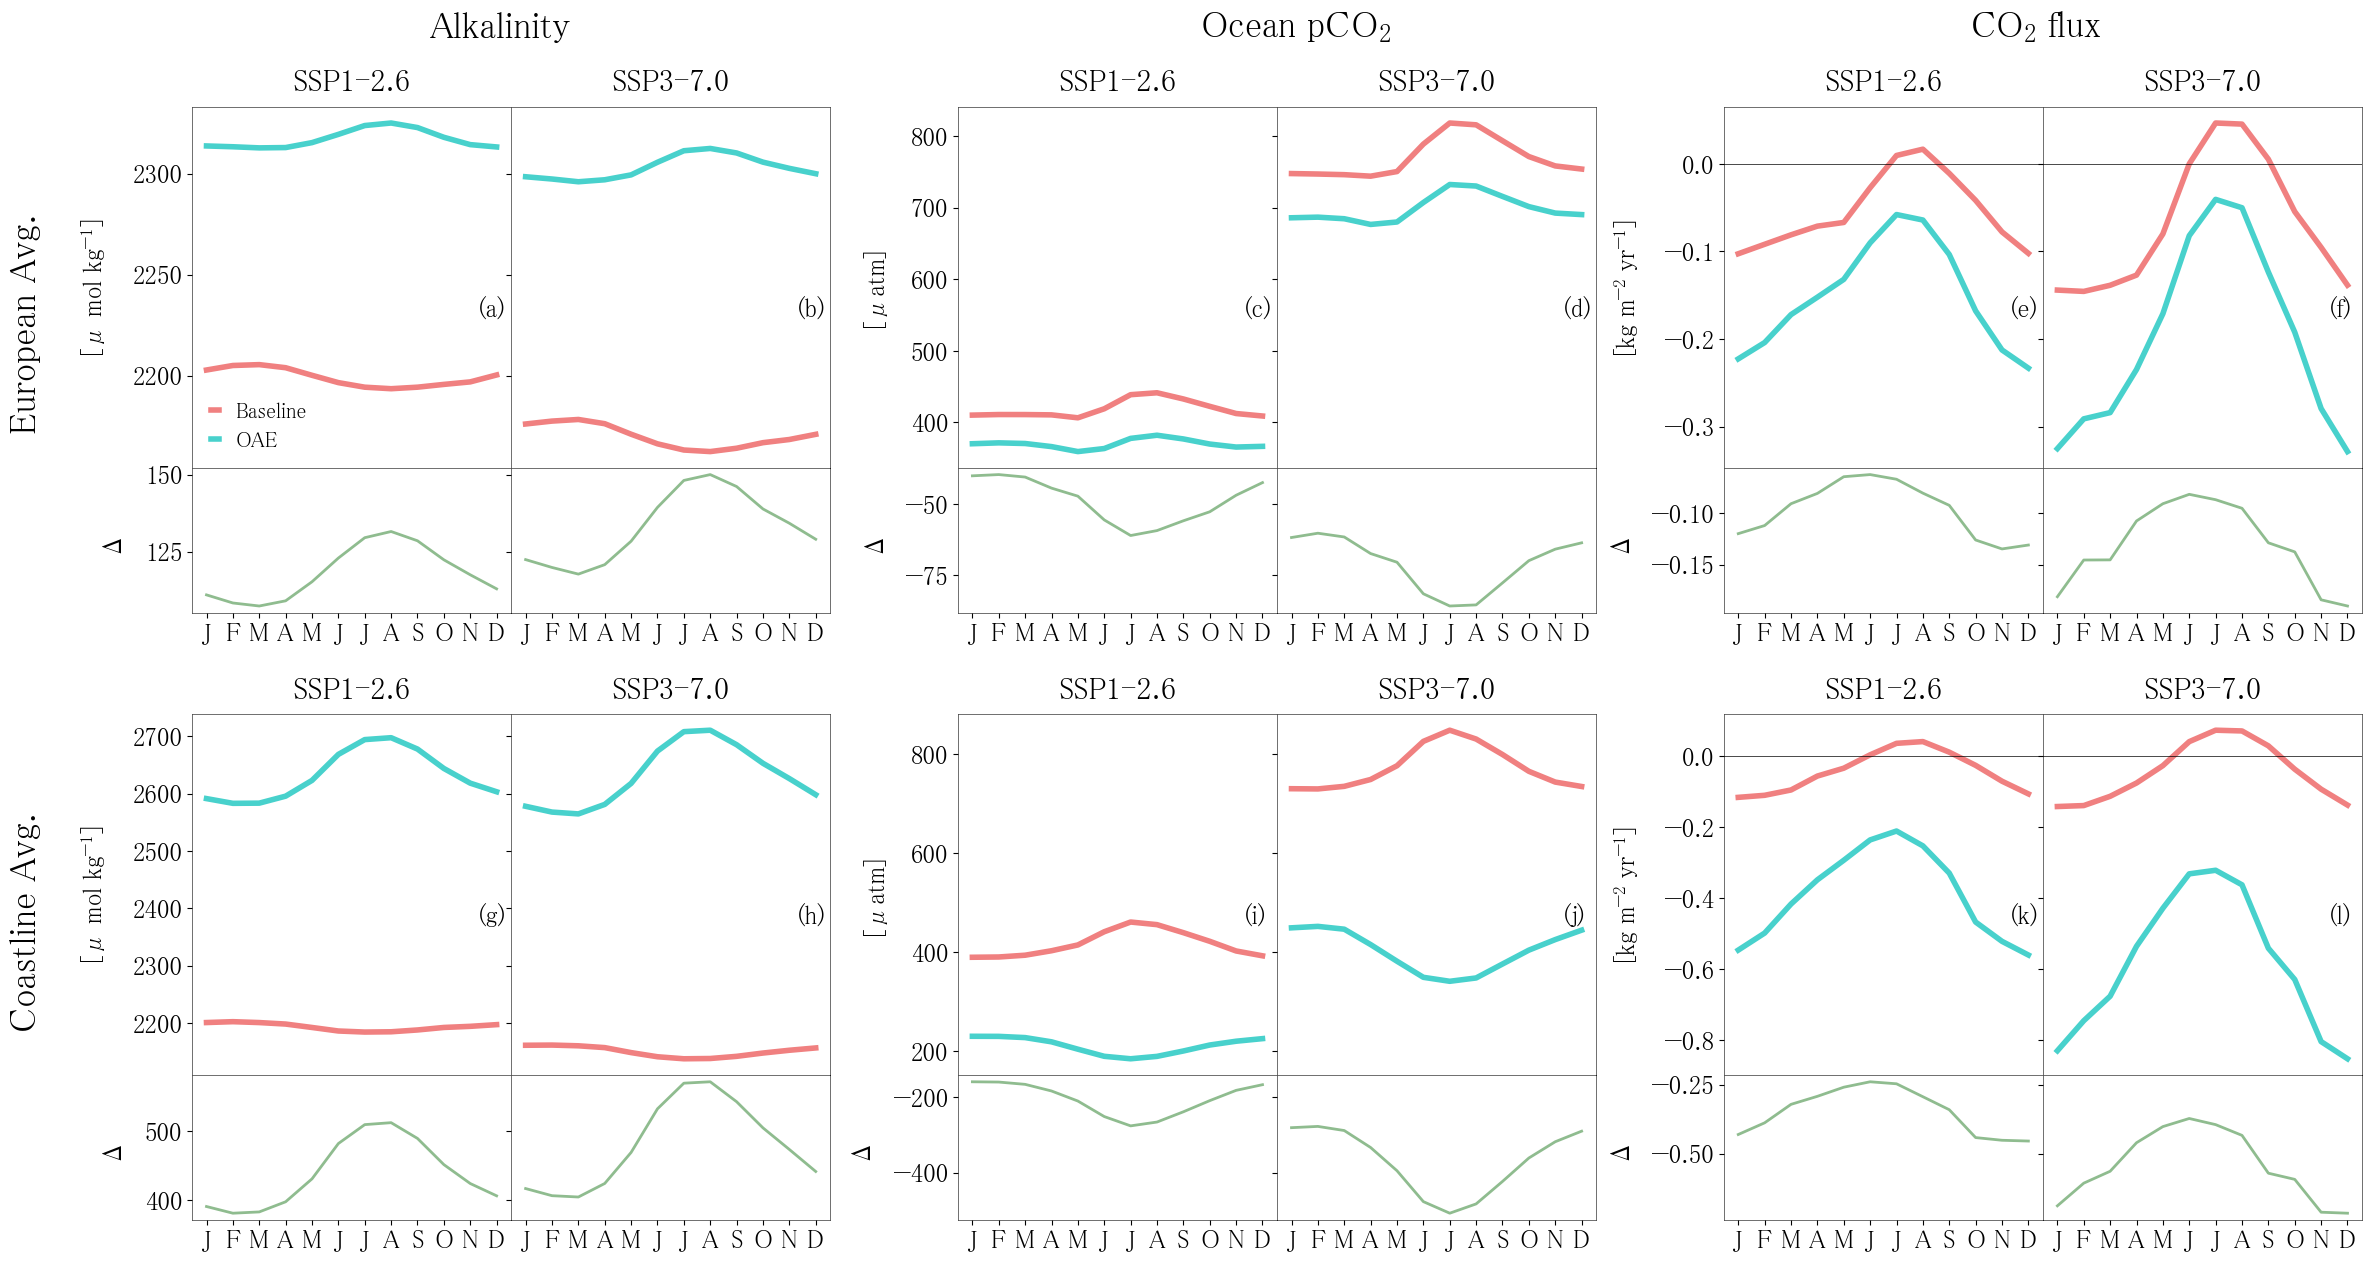

In [27]:
s, m, l = 18, 22, 26

datasets = [eu_alk, eu_pco2, eu_co2flux, ps_alk, ps_pco2, ps_co2flux]
vars = ['ALK','fco2','co2flux','ALK','fco2', 'co2flux']

# datasets = [eu_dic, eu_ph, eu_mld, ps_dic, ps_ph, ps_mld]
# vars = ['DIC','ph','somxl010','DIC','ph', 'somxl010']

point = [58, 60, 41, 43]

labels = ['Baseline', 'OAE']
colors = ['lightcoral', 'mediumturquoise']

def lineplot_vars(ds,var, ax1, ax2, ax3, ax4, labels, colors):
    # abs 
    ax1.plot(list(ds[0].values())[0][var], label=labels[0], color=colors[0], linewidth=4) # baseline ssp126
    ax1.plot(list(ds[0].values())[1][var], label=labels[1], color=colors[1], linewidth=4) # oae ssp126
    ax3.plot(list(ds[0].values())[2][var], label=labels[0], color=colors[0], linewidth=4) # baseline ssp370
    ax3.plot(list(ds[0].values())[3][var], label=labels[1], color=colors[1], linewidth=4) # oae ssp370

    # delta
    ax2.plot(list(ds[1].values())[0][var], color='darkseagreen', linewidth=2) # delta ssp126
    ax4.plot(list(ds[1].values())[1][var], color='darkseagreen', linewidth=2) # delta ssp370

    ax1.set_ylabel(f"[{list(varUnit[var].values())[0]}]", fontsize=s, labelpad=s)
    ax2.set_ylabel(f"Δ", fontsize=s, labelpad=s)

    ax1.set_title('SSP1-2.6', fontsize=m, y=1.02)
    ax3.set_title("SSP3-7.0", fontsize=m, y=1.02)

    ax3.yaxis.set_tick_params(labelleft=False)
    ax4.yaxis.set_tick_params(labelleft=False)

    if var is 'co2flux':
        ax1.axhline(0, color='black', linewidth=0.5)
        ax3.axhline(0, color='black', linewidth=0.5)

gs0 = gridspec.GridSpec(6, 3, hspace=0.2)

axes = []

fig = plt.figure(figsize=(28, 46)) 

for i in range(6):
    gs = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=gs0[i], height_ratios=[1, 0.4], width_ratios=[1, 1], hspace=0, wspace=0)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[0, 1], sharey=ax1)
    ax4 = fig.add_subplot(gs[1, 1], sharey=ax2)

    axes.extend([ax1, ax2, ax3, ax4])
    
    lineplot_vars(datasets[i], vars[i], ax1, ax2, ax3, ax4, labels, colors)

    if i == 0:
            ax1.legend(labels=labels, loc='best', frameon=False, handlelength=.4)

for i, ax in enumerate(axes):
    ax.tick_params(axis='both', which='major', labelsize=s)

    y = list(range(0,13))
    ax.set_xticks(np.arange(min(y), max(y), 1))
    labels = [item.get_text() for item in ax.get_xticklabels()]
    month_label = ['J','F','M','A','M','J','J','A','S','O','N','D']

    if i % 2 != 0:
        ax.set_xticklabels(month_label, fontsize=s)
    else:
        ax.xaxis.set_tick_params(labelleft=False) 

for location in ['left', 'bottom', 'right', 'top']:
    for ax in axes:
        ax.spines[location].set_linewidth(0.4)    

for n, ax in enumerate([axes[i] for i in range(0, 24, 2)]):
    ax.text(0.9, 0.42, f"{string.punctuation[7]}{string.ascii_lowercase[n]}{string.punctuation[8]}",
        transform=ax.transAxes, size=18, color='black')

column_titles = [f"{list(varUnit[vars[0]].keys())[0]}", f"{list(varUnit[vars[1]].keys())[0]}", f"{list(varUnit[vars[2]].keys())[0]}"]
for i, title in enumerate(column_titles):
    fig.text(0.21 + i * 0.275, 0.895, title, fontsize=l)

# Add row titles
row_titles = ['European Avg.', 'Coastline Avg.']
for i, title in enumerate(row_titles):
    fig.text(0.06, 0.81 - i * 0.13,title, ha='left', fontsize=l, rotation=90)

plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/out/lineplot.png', transparent=True)
# plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/out/lineplot_supplement.png', transparent=True)


pass

In [23]:
cmap, norm = create_discrete_cmap(cm.seasons, 40)
cmap.set_bad(color='silver')

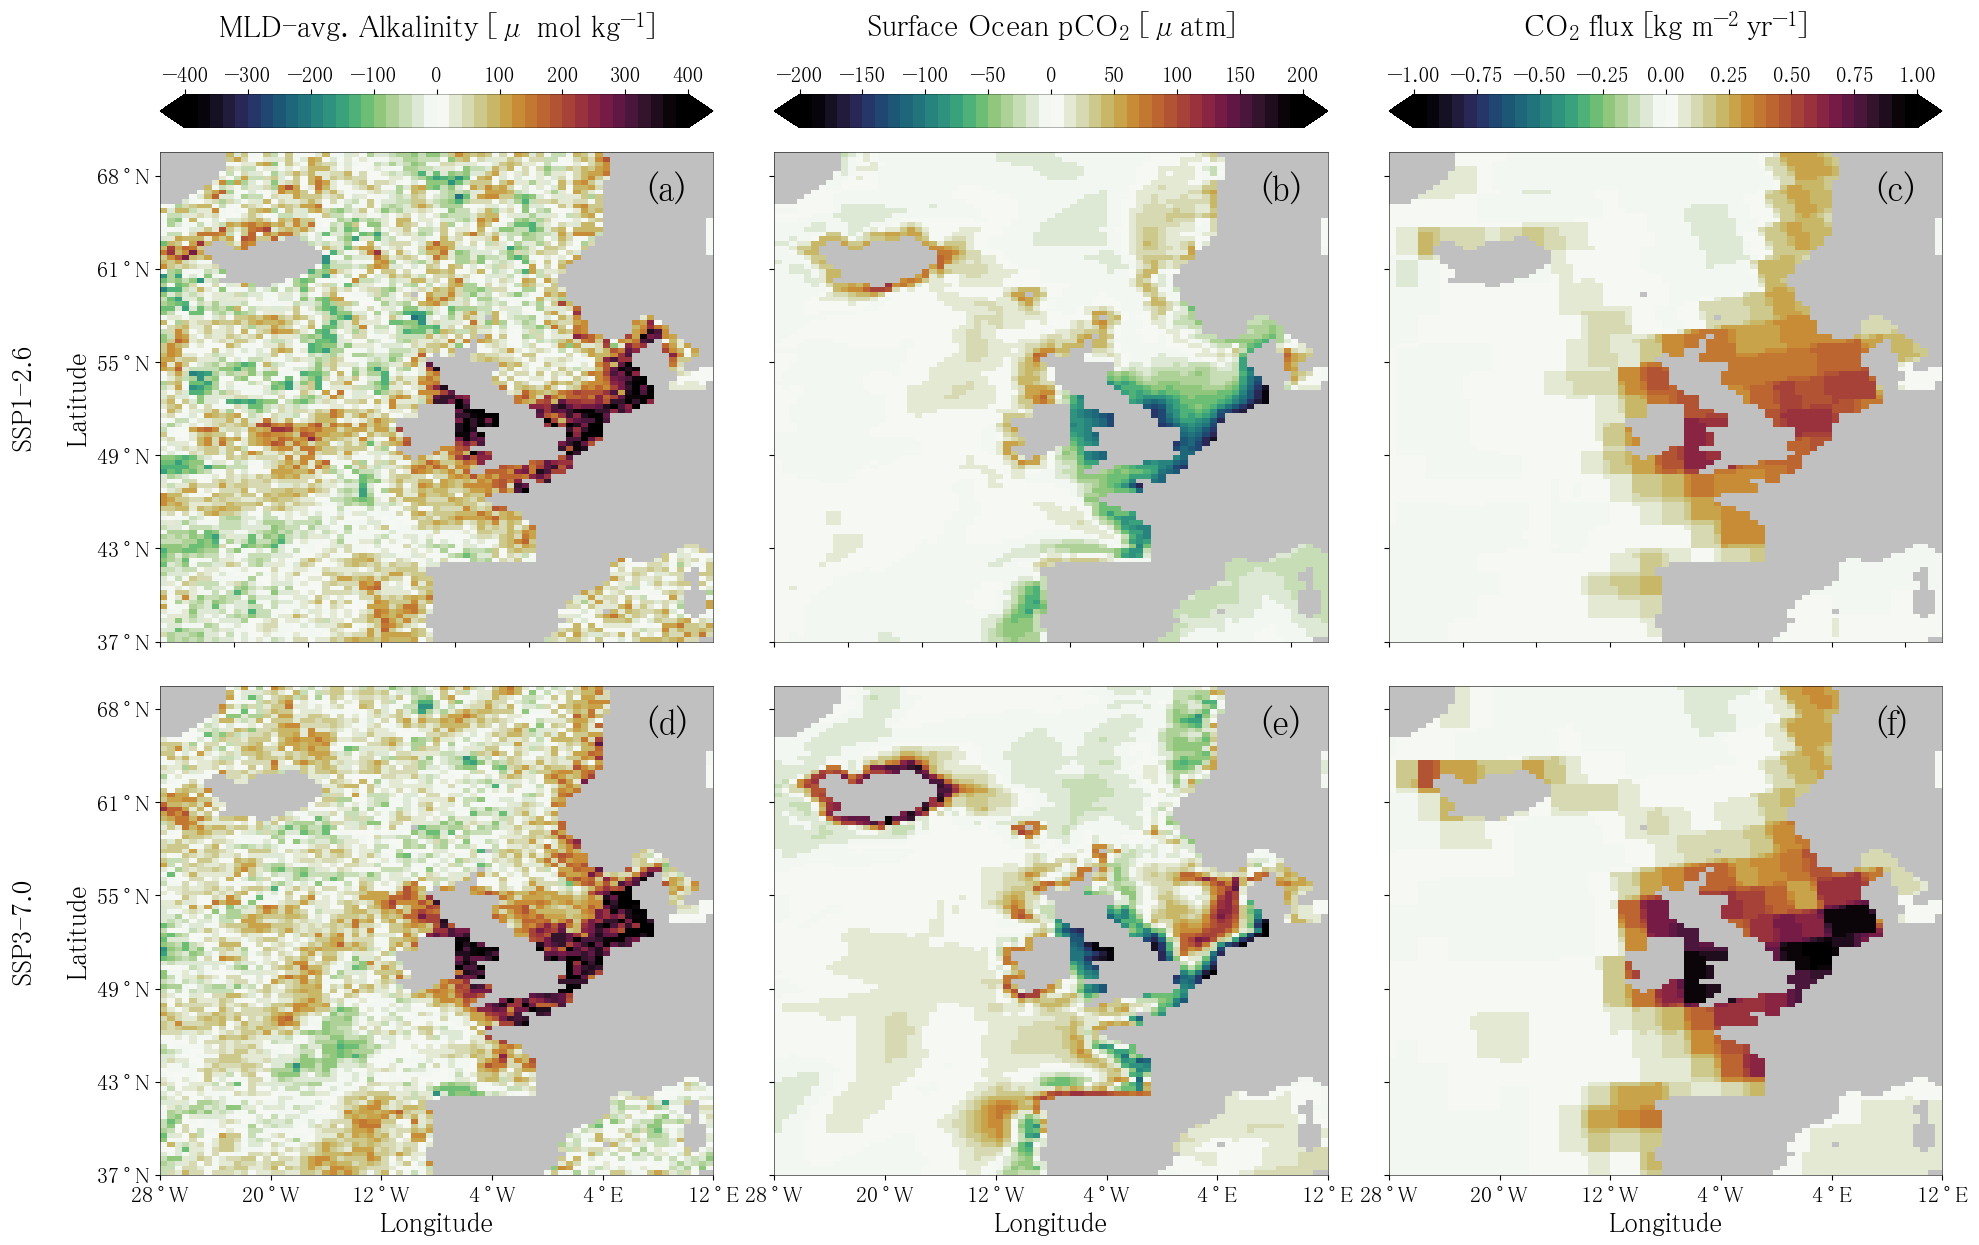

In [26]:
s, m, l = 16, 22, 26

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2,3, figsize=(23, 16))
plt.subplots_adjust(wspace=0.11, hspace=0.09)

plt.rcParams['axes.linewidth'] = .2

datasets = [ampl_alk, ampl_pco2, ampl_co2flux]
vars = ['ALK','fco2','co2flux']
num1,num2,num3 = 400,200,1

# datasets = [ampl_dic, ampl_ph, ampl_mld]
# vars = ['DIC','ph','somxl010','DIC','ph', 'somxl010']
# num1,num2,num3 = 600,.1,200

im1 = fig_plot_map(datasets[0], vars[0], ax1, vmin=-num1, vmax=num1, oae_index=1, base_index=0)
im2 = fig_plot_map(datasets[1], vars[1], ax2, vmin=-num2, vmax=num2, oae_index=1, base_index=0)
im3 = fig_plot_map(datasets[2], vars[2], ax3, vmin=-num3, vmax=num3, oae_index=1, base_index=0)
im4 = fig_plot_map(datasets[0], vars[0], ax4, vmin=-num1, vmax=num1, oae_index=3, base_index=2)
im5 = fig_plot_map(datasets[1], vars[1], ax5, vmin=-num2, vmax=num2, oae_index=3, base_index=2)
im6 = fig_plot_map(datasets[2], vars[2], ax6, vmin=-num3, vmax=num3, oae_index=3, base_index=2)

axes = [ax1, ax2, ax3, ax4, ax5, ax6]
scenarios = ['SSP1-2.6','SSP3-7.0']

for i, (ax, scen) in enumerate(zip([ax1, ax4], scenarios)):
    ax.set_ylabel(f'{scenarios[i]}\n\nLatitude')

for location in ['left', 'bottom', 'right', 'top']:
    for ax in axes:
        ax.spines[location].set_linewidth(0.4)        
        
for ax in axes: 
    lat_label = lat_label
    lon_label = lon_label
        
    if ax in [ax1,ax4]:
        ax.set_yticklabels(lat_label, fontsize=s)        
    else:
        ax.yaxis.set_tick_params(labelleft=False)
        
    if ax in [ax4,ax5,ax6]:
        ax.set_xticks([0,15,30,45,60,75])
        ax.set_xlabel('Longitude')
        ax.set_xticklabels(lon_label, fontsize=s)
    else:
        ax.xaxis.set_tick_params(labelleft=False) 
        
    ax1.set_title(f"MLD-avg. {list(varUnit[vars[0]].keys())[0]} [{list(varUnit[vars[0]].values())[0]}]", fontsize=m, y=1.22)
    ax2.set_title(f"Surface {list(varUnit[vars[1]].keys())[0]} [{list(varUnit[vars[1]].values())[0]}]", fontsize=m, y=1.22),
    ax3.set_title(f"{list(varUnit[vars[2]].keys())[0]} [{list(varUnit[vars[2]].values())[0]}]", fontsize=m, y=1.22),
        
for n, ax in enumerate(axes):
    ax.text(0.88, 0.9, string.punctuation[7] + string.ascii_lowercase[n] + string.punctuation[8],
            transform=ax.transAxes, size=l, weight='bold', color='black')

ims = [im1,im2,im3]
axes = [[ax1,ax4],[ax2,ax5],[ax3,ax6]]

for im, axes in zip(ims, axes):
    cbar = fig.colorbar(im, ax=axes, aspect=15, pad=0.02, location='top', extend='both')
    
# fig.suptitle('OAE-baseline seasonal amplitude difference')
# pass

plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/out/map.png', transparent=True)
# plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/out/map_supplement.png', transparent=True)

In [20]:
cmap, norm = create_discrete_cmap(cm.seasons, 40)
cmap.set_bad('silver')

In [21]:
dic=xr.open_dataset(dataPath+'DIC_base26_lastDecade.nc')
slice_zero = dic['DIC'].sel(deptht=0, method='nearest').isel(time_counter=0)

In [22]:
                  
ssp126_pt = ((list(dic_integral.values())[1]-list(dic_integral.values())[0])).sum(dim=['x','y']).isel(year=-1)
ssp370_pt = ((list(dic_integral.values())[3]-list(dic_integral.values())[2])).sum(dim=['x','y']).isel(year=-1)

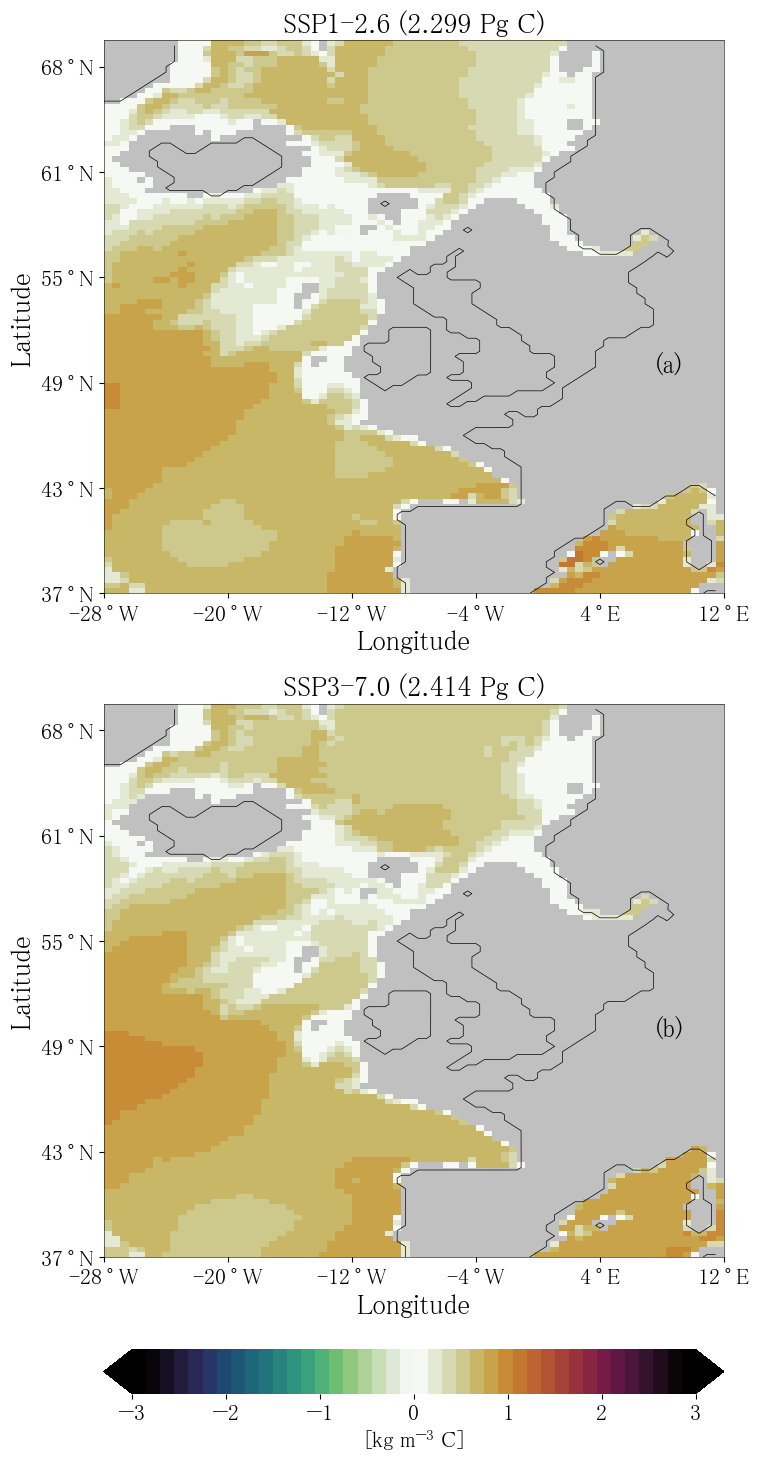

In [65]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8, 20))

s, m, l = 10, 16, 20

v=3
im = fig_plot_map(dic_integral, 'DIC', ax1, vmin=-v, vmax=v, oae_index=1, base_index=0)
im = fig_plot_map(dic_integral, 'DIC', ax2, vmin=-v, vmax=v, oae_index=3, base_index=2)

axes = [ax1,ax2]

for ax in axes: 
    lat_label = lat_label
    lon_label = lon_label
        
    ax.set_xticks([0,15,30,45,60,75])        
        
    ax.set_yticklabels(lat_label, fontsize=m)     
    ax.set_xticklabels(lon_label, fontsize=m)

    ax.tick_params(axis='both', which='major', labelsize=m)
    # ax.text(53, 49,'point S', fontsize=s, color='black')
    # ax.plot(57, 44, marker = 'o', color='black')
    
    slice_zero.plot.contour(ax=ax, levels=1, linewidths=.5, colors='black')   
    # slice_200.plot.contour(ax=ax, levels=1, linewidths=.5, colors='black')   
    
    ax.set_xlabel('Longitude', fontsize=l)
    ax.set_ylabel('Latitude', fontsize=l)

for location in ['left', 'bottom', 'right', 'top']:
    for ax in axes:
        ax.spines[location].set_linewidth(0.4) 

cbar = fig.colorbar(im, ax=[ax1,ax2], aspect=14, pad=0.06, location='bottom', extend='both')
cbar.set_label(r'[kg $\mathregular{m^{-3}}$ C]', fontsize=m)
cbar.ax.set_frame_on(False)

ax1.set_title(f"SSP1-2.6 ({round((ssp126_pt['DIC']).item()*1e-3, 3)} Pg C)", fontsize=l)
ax2.set_title(f"SSP3-7.0 ({round((ssp370_pt['DIC']).item()*1e-3, 3)} Pg C)", fontsize=l)

for n, ax in enumerate([ax1,ax2]):
    ax.text(0.89, 0.40, f"{string.punctuation[7]}{string.ascii_lowercase[n]}{string.punctuation[8]}",
        transform=ax.transAxes, size=18, color='black')

# fig.suptitle('DIC integral below the mixed layer in SSP1-2.6 (left) and SSP3-7.0 (right)', fontsize=m)

for t in cbar.ax.get_xticklabels():
     t.set_fontsize(m)
        
pass

# plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/out/DICintegral_totald.png', transparent=True)

In [24]:
var = 'ph'

# load datasets
var_datasets = {
    scenario: xr.open_dataset(path, decode_times=True)
    for scenario, path in filePath[var].items()
}

ph_final = {}

for scenario, dataset in var_datasets.items():
    dataset = dataset.where(dataset)
    dataset = geo_weight(dataset, var)
    ph_mean = dataset.groupby('time_counter.year').mean('time_counter').mean('year')
    ph_cng_final = dataset - ph_mean
    ph_final[scenario] = ph_cng_final

In [26]:
# fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20,10))

# color_map = {
#     'Baseline': 'lightcoral',
#     'OAE': 'mediumturquoise',
# }
# s=12
# linestyle = 'dashed'

# for scen, data in ph_final.items():
#     label = 'Baseline' if 'base' in scen else 'OAE'
#     color = color_map[label]

#     ax = ax1 if '26' in scen else ax2

#     ax.plot(data.time_counter, data[var], label=label, linewidth=3, color=color)

#     regr = lin_regr(data, var)
#     ax.plot(data.time_counter, regr, linewidth=1, linestyle=linestyle, color=color)
    
#     ax.axhline(0, color='black', linewidth=.1)
#     # ax.set_ylim(-.045, .045)
#     ax.set_ylabel('Δ pH')
    
#     ax.tick_params(axis='both', which='major', labelsize=s)
#     for location in ['left', 'bottom', 'right', 'top']:
#         ax.spines[location].set_linewidth(0.4)    

# ax1.legend(frameon=False, handlelength=.4)
# ax1.set_title('SSP1-2.6')
# ax2.set_title('SSP3-7.0')

# # plt.savefig('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/out/phcycle.png', transparent=True)